In [16]:
import pandas as pd
from pathlib import Path

raiz_do_projeto = Path().absolute().parent if "notebooks" in str(Path().absolute()) else Path().absolute()
caminho_csv = raiz_do_projeto / "data" / "raw" / "DATASETFINAL - DATASETFINAL.csv"

tabela = pd.read_csv(caminho_csv)
tabela

,task_id,titulo,descricao,prioridade,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,data_conclusao,status_atual,feedback_conclusao_ mentorado
0,1,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,NaN,andamento,NaN
1,2,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,2026-04-02,concluida,NaN
2,3,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,2026-04-06,concluida,NaN
3,4,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,2026-04-27,concluida,NaN
4,5,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,2026-03-19,concluida,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
71,72,Refatorar Pipeline CI/CD - Sprint 7,Atividade focada em refatorar o recurso de pip...,media,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-03,2026-03-04,2026-03-23,concluida,NaN
72,73,Implementar Exportação de Relatórios - Sprint 10,Atividade focada em implementar o recurso de e...,media,Camila Lopes,Produto,Juliana Costa,2026-05-11,NaN,NaN,pendente,NaN
73,74,Ajustar Dashboard - Sprint 6,Atividade focada em ajustar o recurso de dashb...,media,Eduarda Souza,DevFront-end,Juliana Costa,2026-03-03,2026-03-04,2026-03-09,concluida,NaN
74,75,Atualizar Fluxo de Autenticação - Sprint 10,Atividade focada em atualizar o recurso de flu...,alta,Gabriela Pinto,DevMobile,Juliana Costa,2026-05-03,2026-05-06,2026-05-10,concluida,NaN


In [17]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   task_id                        76 non-null     int64  
 1   titulo                         76 non-null     str    
 2   descricao                      76 non-null     str    
 3   prioridade                     76 non-null     str    
 4   mentorado                      76 non-null     str    
 5   area_atuacao                   76 non-null     str    
 6   mentor_responsavel             76 non-null     str    
 7   data_criacao                   76 non-null     str    
 8   data_inicio                    62 non-null     str    
 9   data_conclusao                 43 non-null     str    
 10  status_atual                   76 non-null     str    
 11  feedback_conclusao_ mentorado  0 non-null      float64
dtypes: float64(1), int64(1), str(10)
memory usage: 7.3 KB


,task_id,feedback_conclusao_ mentorado
count,76.000000,0.0
mean,38.500000,NaN
std,22.083176,NaN
min,1.000000,NaN
25%,19.750000,NaN
50%,38.500000,NaN
75%,57.250000,NaN
max,76.000000,NaN


In [18]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           62 non-null     datetime64[us]
 2   data_conclusao        43 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.5 KB


In [19]:
# 1. Média de dias para concluir uma tarefa
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias")
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [20]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 43 tarefas (56.6%)
• andamento: 19 tarefas (25.0%)
• pendente: 14 tarefas (18.4%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
DevBack-end      3
UX/UIDesigner    3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         43        14


C:\Users\jcc\AppData\Local\Temp\ipykernel_26920\1599355491.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


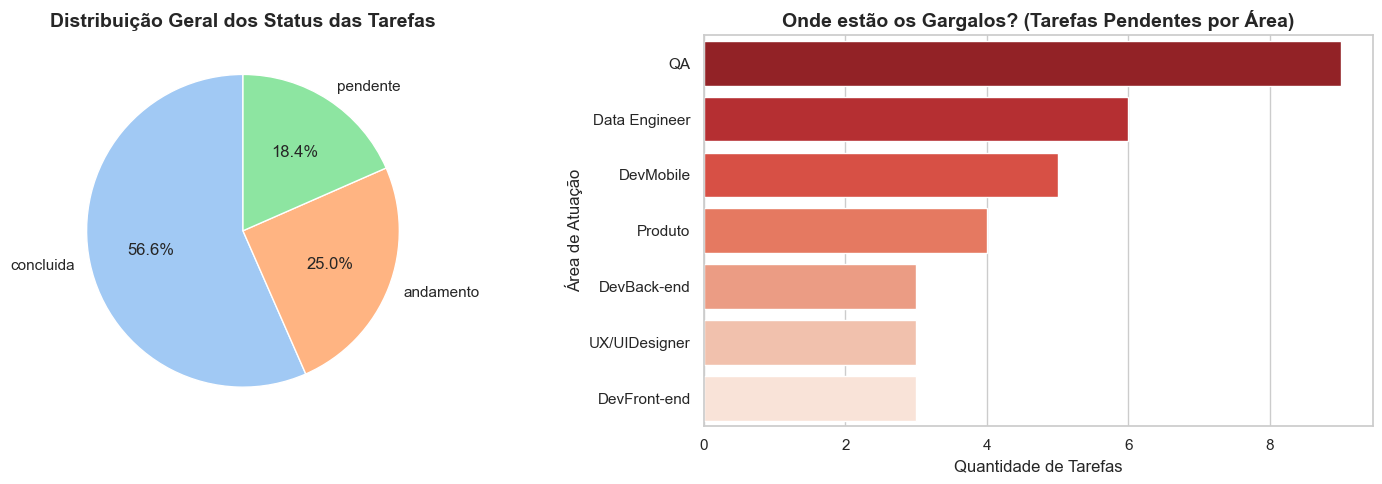

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()